In [ ]:
%pip install -U imbalanced-learn
%load_ext autoreload
%autoreload 2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from custom_func import feature_engineering, clean_data_from_outliers,encode_categorical_features,scale_numerical_features
from sklearn.preprocessing import MinMaxScaler,OneHotEncoder,OrdinalEncoder,StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from imblearn.datasets import fetch_datasets
from sklearn.metrics import classification_report, precision_score, recall_score


pd.set_option('display.max.rows',130)
pd.set_option('display.max.columns',130)
pd.set_option('float_format', '{:.2f}'.format)
scaler = StandardScaler()

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [363]:
df = pd.read_csv('../data/raw/bank-additional-full.csv', sep=';')
df_train,df_test = train_test_split(df, test_size=0.2, random_state=42, stratify=df['y'])
df_train,df_val = train_test_split(df_train, test_size=0.25, random_state=42, stratify=df_train['y'])
df_train.to_csv('../data/processed/train.csv', index=False)
df_val.to_csv('../data/processed/val.csv', index=False)
df_test.to_csv('../data/processed/test.csv', index=False)


In [364]:
df.shape

(41188, 21)

In [365]:
df_train.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
7302,53,retired,married,basic.4y,no,no,no,telephone,may,thu,101,23,999,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no
6693,55,retired,divorced,professional.course,no,no,yes,telephone,may,wed,217,2,999,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no
40376,27,student,single,university.degree,no,yes,no,telephone,aug,wed,153,1,0,5,success,-1.70,94.03,-38.30,0.90,4991.60,no
24387,33,technician,single,university.degree,no,no,no,cellular,nov,mon,69,1,999,0,nonexistent,-0.10,93.20,-42.00,4.19,5195.80,no
33177,27,blue-collar,married,basic.9y,no,yes,no,cellular,may,tue,631,1,11,1,success,-1.80,92.89,-46.20,1.29,5099.10,no


In [366]:
df_train = feature_engineering(df_train)
df_val = feature_engineering(df_val)
df_test = feature_engineering(df_test)

In [367]:
df_train.head()

,job,marital,education,default,housing,loan,contact,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,season,age_group,has_prev_contact,previous_success,avg_success_by_job,avg_success_by_marital,avg_success_by_education,avg_success_by_contact,job_prev_interaction,marital_campaign_interaction,education_empvar_interaction
7302,retired,married,basic.4y,no,no,no,telephone,thu,101,23,999,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no,spring,Middle Age,0,0,0.09,0.03,0.03,0.01,retired_0,Other,basic.4y_1.1
6693,retired,divorced,professional.course,no,no,yes,telephone,wed,217,2,999,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no,spring,Middle Age,0,0,0.09,0.02,0.04,0.01,retired_0,divorced_2,professional.course_1.1
40376,student,single,university.degree,no,yes,no,telephone,wed,153,1,0,5,success,-1.70,94.03,-38.30,0.90,4991.60,no,summer,Young Adult,1,1,0.14,0.05,0.04,0.01,Other,single_1,Other
24387,technician,single,university.degree,no,no,no,cellular,mon,69,1,999,0,nonexistent,-0.10,93.20,-42.00,4.19,5195.80,no,autumn,Young Adult,0,0,0.03,0.05,0.04,0.05,technician_0,single_1,university.degree_-0.1
33177,blue-collar,married,basic.9y,no,yes,no,cellular,tue,631,1,11,1,success,-1.80,92.89,-46.20,1.29,5099.10,no,spring,Young Adult,1,1,0.01,0.03,0.02,0.05,blue-collar_1,married_1,basic.9y_-1.8


In [368]:
df_train['y'] = df_train['y'].map({'yes': 1, 'no': 0}).astype(int)
df_val['y'] = df_val['y'].map({'yes': 1, 'no': 0}).astype(int)
df_test['y'] = df_test['y'].map({'yes': 1, 'no': 0}).astype(int)

numeric_cols = df_train.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df_train.select_dtypes(exclude=np.number).columns.tolist()
numeric_cols.remove('y')


In [369]:
df_train, df_val,df_test = scale_numerical_features( df_train, df_val,df_test, numeric_cols)
df_train.head()

,job,marital,education,default,housing,loan,contact,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,season,age_group,has_prev_contact,previous_success,avg_success_by_job,avg_success_by_marital,avg_success_by_education,avg_success_by_contact,job_prev_interaction,marital_campaign_interaction,education_empvar_interaction
7302,retired,married,basic.4y,no,no,no,telephone,thu,-0.60,7.35,0.20,-0.35,nonexistent,0.65,0.72,0.89,0.71,0.33,0,spring,Middle Age,-0.20,-0.19,2.31,-0.48,-0.30,-1.31,retired_0,Other,basic.4y_1.1
6693,retired,divorced,professional.course,no,no,yes,telephone,wed,-0.16,-0.21,0.20,-0.35,nonexistent,0.65,0.72,0.89,0.71,0.33,0,spring,Middle Age,-0.20,-0.19,2.31,-1.27,0.33,-1.31,retired_0,divorced_2,professional.course_1.1
40376,student,single,university.degree,no,yes,no,telephone,wed,-0.40,-0.56,-5.12,9.64,success,-1.14,0.77,0.47,-1.57,-2.42,0,summer,Young Adult,5.09,5.39,4.66,1.56,1.05,-1.31,Other,single_1,Other
24387,technician,single,university.degree,no,no,no,cellular,mon,-0.73,-0.56,0.20,-0.35,nonexistent,-0.12,-0.65,-0.32,0.33,0.40,0,autumn,Young Adult,-0.20,-0.19,-0.02,1.56,1.05,0.76,technician_0,single_1,university.degree_-0.1
33177,blue-collar,married,basic.9y,no,yes,no,cellular,tue,1.43,-0.56,-5.06,1.65,success,-1.20,-1.18,-1.23,-1.34,-0.93,0,spring,Young Adult,5.09,5.39,-0.84,-0.48,-1.55,0.76,blue-collar_1,married_1,basic.9y_-1.8


In [370]:
for col in categorical_cols:
    print(f"Value Counts for {col}:")
    print(df_train[col].value_counts(normalize=True) * 100)
    print()

Value Counts for job:
job
admin.          25.09
blue-collar     22.69
technician      16.37
services         9.66
management       7.11
retired          4.18
entrepreneur     3.58
self-employed    3.39
housemaid        2.62
unemployed       2.37
student          2.14
unknown          0.81
Name: proportion, dtype: float64

Value Counts for marital:
marital
married    60.63
single     27.86
divorced   11.30
unknown     0.20
Name: proportion, dtype: float64

Value Counts for education:
education
university.degree     29.50
high.school           22.91
basic.9y              14.86
professional.course   12.73
basic.4y              10.07
basic.6y               5.63
unknown                4.31
Name: proportion, dtype: float64

Value Counts for default:
default
no        79.00
unknown   20.99
yes        0.01
Name: proportion, dtype: float64

Value Counts for housing:
housing
yes       52.40
no        45.16
unknown    2.43
Name: proportion, dtype: float64

Value Counts for loan:
loan
no        82

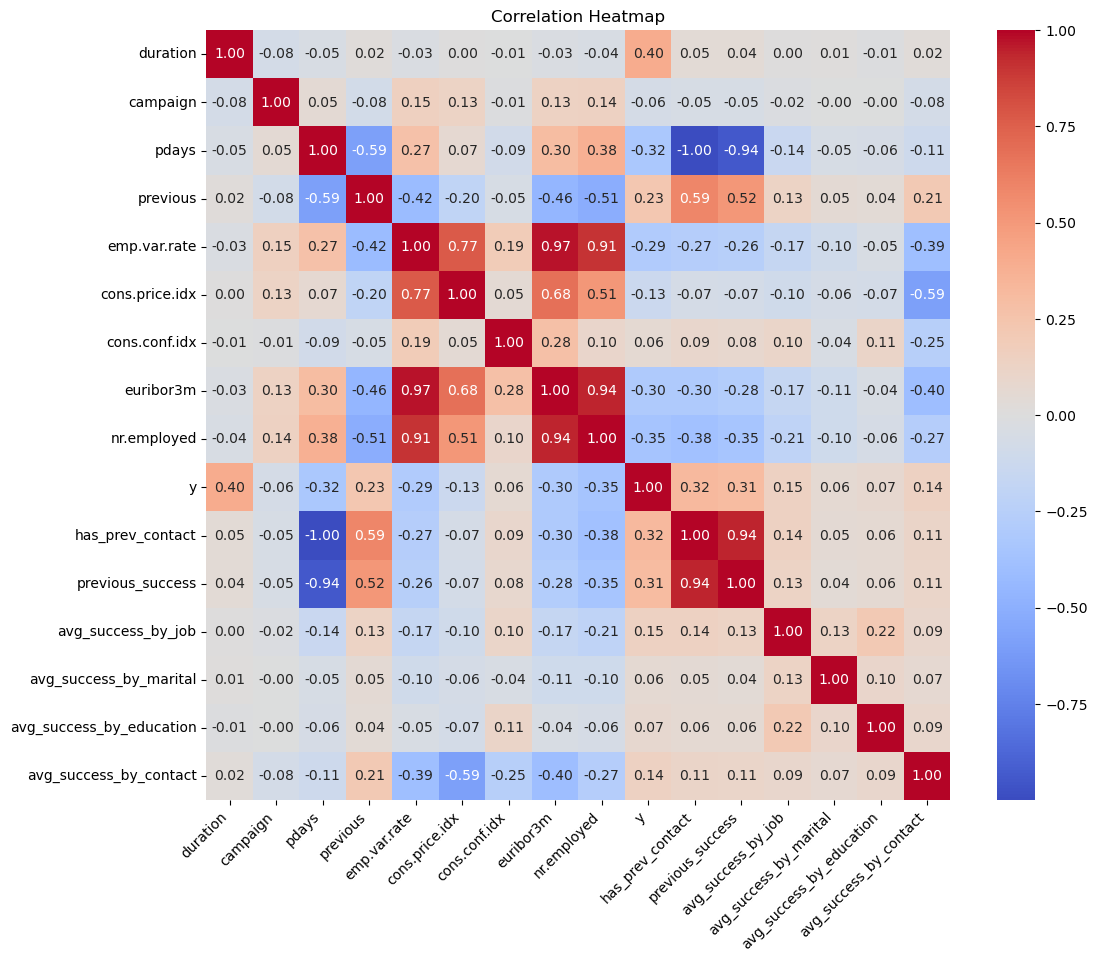

In [371]:
import plotly.express as px
corr = df_train.corr(numeric_only=True)
plt.figure(figsize=(12, 10))  # big enough for 20 cols
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.title("Correlation Heatmap")
plt.show()

In [372]:
categorical_cols = df_train.select_dtypes(exclude=np.number).columns.tolist()
for col in categorical_cols:
    print(f"Value Counts for {col}:")
    print(df_train[col].value_counts(normalize=True) * 100)
    print()

Value Counts for job:
job
admin.          25.09
blue-collar     22.69
technician      16.37
services         9.66
management       7.11
retired          4.18
entrepreneur     3.58
self-employed    3.39
housemaid        2.62
unemployed       2.37
student          2.14
unknown          0.81
Name: proportion, dtype: float64

Value Counts for marital:
marital
married    60.63
single     27.86
divorced   11.30
unknown     0.20
Name: proportion, dtype: float64

Value Counts for education:
education
university.degree     29.50
high.school           22.91
basic.9y              14.86
professional.course   12.73
basic.4y              10.07
basic.6y               5.63
unknown                4.31
Name: proportion, dtype: float64

Value Counts for default:
default
no        79.00
unknown   20.99
yes        0.01
Name: proportion, dtype: float64

Value Counts for housing:
housing
yes       52.40
no        45.16
unknown    2.43
Name: proportion, dtype: float64

Value Counts for loan:
loan
no        82

In [373]:
numeric_cols = df_train.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df_train.select_dtypes(exclude=np.number).columns.tolist()
categorical_cols

['job',
 'marital',
 'education',
 'default',
 'housing',
 'loan',
 'contact',
 'day_of_week',
 'poutcome',
 'season',
 'age_group',
 'job_prev_interaction',
 'marital_campaign_interaction',
 'education_empvar_interaction']

In [374]:
df_train,df_val,df_test,encoded_cols = encode_categorical_features(df_train, df_val, df_test, categorical_cols)
df_train.head()

c:\DASHA\ML\git\ml_learning\MidTermProject\notebooks\preprocess_data.py:231: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

c:\DASHA\ML\git\ml_learning\MidTermProject\notebooks\preprocess_data.py:231: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

c:\DASHA\ML\git\ml_learning\MidTermProject\notebooks\preprocess_data.py:231: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) in

Drop: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'day_of_week', 'poutcome', 'season', 'age_group', 'job_prev_interaction', 'marital_campaign_interaction', 'education_empvar_interaction']


c:\DASHA\ML\git\ml_learning\MidTermProject\notebooks\preprocess_data.py:234: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

c:\DASHA\ML\git\ml_learning\MidTermProject\notebooks\preprocess_data.py:234: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

c:\DASHA\ML\git\ml_learning\MidTermProject\notebooks\preprocess_data.py:234: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) in

,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,has_prev_contact,previous_success,avg_success_by_job,avg_success_by_marital,avg_success_by_education,avg_success_by_contact,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,job_unknown,marital_divorced,marital_married,marital_single,marital_unknown,education_basic.4y,education_basic.6y,education_basic.9y,education_high.school,education_professional.course,education_university.degree,education_unknown,default_no,default_unknown,default_yes,housing_no,housing_unknown,housing_yes,loan_no,loan_unknown,loan_yes,contact_cellular,contact_telephone,day_of_week_fri,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_failure,poutcome_nonexistent,poutcome_success,season_autumn,season_spring,season_summer,season_winter,age_group_Adult,age_group_Child,age_group_Middle Age,age_group_Senior,age_group_Young Adult,job_prev_interaction_Other,job_prev_interaction_admin._0,job_prev_interaction_admin._1,job_prev_interaction_blue-collar_0,job_prev_interaction_blue-collar_1,job_prev_interaction_entrepreneur_0,job_prev_interaction_housemaid_0,job_prev_interaction_management_0,job_prev_interaction_retired_0,job_prev_interaction_self-employed_0,job_prev_interaction_services_0,job_prev_interaction_services_1,job_prev_interaction_student_0,job_prev_interaction_technician_0,job_prev_interaction_technician_1,job_prev_interaction_unemployed_0,marital_campaign_interaction_Other,marital_campaign_interaction_divorced_1,marital_campaign_interaction_divorced_2,marital_campaign_interaction_divorced_3,marital_campaign_interaction_married_1,marital_campaign_interaction_married_2,marital_campaign_interaction_married_3,marital_campaign_interaction_married_4,marital_campaign_interaction_married_5,marital_campaign_interaction_married_6,marital_campaign_interaction_single_1,marital_campaign_interaction_single_2,marital_campaign_interaction_single_3,marital_campaign_interaction_single_4,marital_campaign_interaction_single_5,education_empvar_interaction_Other,education_empvar_interaction_basic.4y_-1.8,education_empvar_interaction_basic.4y_1.1,education_empvar_interaction_basic.4y_1.4,education_empvar_interaction_basic.6y_-1.8,education_empvar_interaction_basic.6y_1.1,education_empvar_interaction_basic.6y_1.4,education_empvar_interaction_basic.9y_-0.1,education_empvar_interaction_basic.9y_-1.8,education_empvar_interaction_basic.9y_1.1,education_empvar_interaction_basic.9y_1.4,education_empvar_interaction_high.school_-0.1,education_empvar_interaction_high.school_-1.8,education_empvar_interaction_high.school_1.1,education_empvar_interaction_high.school_1.4,education_empvar_interaction_professional.course_-0.1,education_empvar_interaction_professional.course_-1.8,education_empvar_interaction_professional.course_1.1,education_empvar_interaction_professional.course_1.4,education_empvar_interaction_university.degree_-0.1,education_empvar_interaction_university.degree_-1.8,education_empvar_interaction_university.degree_-2.9,education_empvar_interaction_university.degree_-3.4,education_empvar_interaction_university.degree_1.1,education_empvar_interaction_university.degree_1.4,education_empvar_interaction_unknown_1.4
7302,-0.60,7.35,0.20,-0.35,0.65,0.72,0.89,0.71,0.33,0,-0.20,-0.19,2.31,-0.48,-0.30,-1.31,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
6693,-0.16,-0.21,0.20,

In [375]:
df_train.to_csv('../data/processed/DecTree/train_encoded.csv', index=False)
df_val.to_csv('../data/processed/DecTree/val_encoded.csv', index=False)     
df_test.to_csv('../data/processed/DecTree/test_encoded.csv', index=False)

In [376]:
df_train = clean_data_from_outliers(df_train, column='duration')

Removing outliers from 'duration' using IQR method:
Q1: -0.60, Q3: 0.23, IQR: 0.83
Lower bound: -1.84, Upper bound: 1.48
Original dataset shape: (24712, 124)
Dataset shape after outlier removal: (22941, 124)


In [ ]:
df_train.to_csv('../data/processed/LR/train_encoded.csv', index=False) 
df_val.to_csv('../data/processed/LR/val_encoded.csv', index=False)     
df_test.to_csv('../data/processed/LR/test_encoded.csv', index=False)

In [ ]:
df_train_without_duration = df_train.drop(columns=['duration'])
df_val_without_duration = df_val.drop(columns=['duration'])
df_test_without_duration = df_test.drop(columns=['duration'])
df_train_without_duration.to_csv('../data/processed/LR/train_encoded_without_duration.csv', index=False) 
df_val_without_duration.to_csv('../data/processed/LR/val_encoded_without_duration.csv', index=False)     
df_test_without_duration.to_csv('../data/processed/LR/test_encoded_without_duration.csv', index=False)

In [379]:
df_train.columns

Index(['duration', 'campaign', 'pdays', 'previous', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y',
       ...
       'education_empvar_interaction_professional.course_-1.8',
       'education_empvar_interaction_professional.course_1.1',
       'education_empvar_interaction_professional.course_1.4',
       'education_empvar_interaction_university.degree_-0.1',
       'education_empvar_interaction_university.degree_-1.8',
       'education_empvar_interaction_university.degree_-2.9',
       'education_empvar_interaction_university.degree_-3.4',
       'education_empvar_interaction_university.degree_1.1',
       'education_empvar_interaction_university.degree_1.4',
       'education_empvar_interaction_unknown_1.4'],
      dtype='object', length=124)